# ==============================
# DIVISIVE HIERARCHICAL CLUSTERING
# ==============================

"""
Objective:
Apply Divisive Hierarchical Clustering on student performance data (1Y, 2Y, 3Y) 
to identify natural groupings based on student characteristics and performance metrics.

Methodology:
1️⃣ Data Preparation: Select relevant features for clustering.
2️⃣ Feature Scaling using StandardScaler.
3️⃣ PCA for dimensionality reduction (optional, for visualization).
4️⃣ Apply Divisive Clustering (Top-down approach):
   - Start with all points in one cluster
   - Recursively split clusters to maximize dissimilarity
5️⃣ Evaluate cluster quality using silhouette score.
6️⃣ Visualize clusters in 2D PCA space.
"""

In [4]:
# ==============================
# STEP 0: LOAD DATASETS
# ==============================

import pandas as pd

# 🔹 Load datasets using relative paths
df1 = pd.read_csv("../data/1y_final_clean_encoded.csv")  # 1st-year dataset
df2 = pd.read_csv("../data/2y_final_clean_encoded.csv")  # 2nd-year dataset
df3 = pd.read_csv("../data/3y_final_clean_encoded.csv")  # 3rd-year dataset

# 🔹 Quick check of first rows
print("1Y Data:")
print(df1.head())
print("\n2Y Data:")
print(df2.head())
print("\n3Y Data:")
print(df3.head())

# 🔹 Check shapes
print("\nShapes:")
print("1Y:", df1.shape)
print("2Y:", df2.shape)
print("3Y:", df3.shape)


1Y Data:
   record_id  gender  study_year  bac_specialty  study_hours_per_week  \
0          1       1           2              2                     0   
1          2       0           2              0                     1   
2          3       0           2              2                     0   
3          4       1           2              0                     0   
4          5       1           2              1                     0   

   preferred_study_place  preferred_study_time  learning_methods  \
0                      0                     0                22   
1                      2                     0                54   
2                      3                     0                14   
3                      2                     2                54   
4                      2                     0                54   

   study_resources  uses_planner  ...  1y english 2  1y intensive english  \
0               16             0  ...             2               

In [5]:
# ==============================
# STEP 1: DATA PREPARATION & FEATURE SELECTION
# ==============================

import numpy as np

# 🔹 Drop non-feature columns
X1 = df1.drop(columns=['record_id', 'study_year'])

# 🔹 Keep only numeric columns
X1 = X1.select_dtypes(include=[np.number])

# 🔹 Check resulting shape
print("1Y features shape:", X1.shape)
print(X1.head())


1Y features shape: (210, 55)
   gender  bac_specialty  study_hours_per_week  preferred_study_place  \
0       1              2                     0                      0   
1       0              0                     1                      2   
2       0              2                     0                      3   
3       1              0                     0                      2   
4       1              1                     0                      2   

   preferred_study_time  learning_methods  study_resources  uses_planner  \
0                     0                22               16             0   
1                     0                54               36             1   
2                     0                14               31             1   
3                     2                54               34             0   
4                     0                54               34             0   

   problem_1  2 second  ...  1y english 2  1y intensive english  1y seminar

In [6]:
# ==============================
# STEP 1: DATA PREPARATION & FEATURE SELECTION
# ==============================

import numpy as np

# 🔹 2Y dataset
X2 = df2.drop(columns=['record_id', 'study_year'])
X2 = X2.select_dtypes(include=[np.number])
print("2Y features shape:", X2.shape)
print(X2.head())

# 🔹 3Y dataset
X3 = df3.drop(columns=['record_id', 'study_year'])
X3 = X3.select_dtypes(include=[np.number])
print("3Y features shape:", X3.shape)
print(X3.head())


2Y features shape: (101, 62)
   gender  bac_specialty  study_hours_per_week  preferred_study_place  \
0       1              0                     0                      1   
1       0              0                     0                      1   
2       1              0                     0                      1   
3       1              0                     0                      1   
4       0              1                     1                      1   

   preferred_study_time  learning_methods  study_resources  uses_planner  \
0                     2                46               29             0   
1                     0                16               27             1   
2                     1                17               29             0   
3                     0                 0               14             0   
4                     0                45               20             1   

   problem_1  problem_2  ...  2y complexity  2y proba stat ii  2y lin alg i

In [10]:
# ==============================
# STEP #: FEATURE SCALING
# ==============================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 🔹 Scale each year’s features
X1_scaled = scaler.fit_transform(X1)
X2_scaled = scaler.fit_transform(X2)
X3_scaled = scaler.fit_transform(X3)

# 🔹 Quick check
print("1Y scaled mean/std (first 5 columns):")
print(pd.DataFrame(X1_scaled, columns=X1.columns).iloc[:, :5].describe().loc[['mean','std']])
print("\n2Y scaled mean/std (first 5 columns):")
print(pd.DataFrame(X2_scaled, columns=X2.columns).iloc[:, :5].describe().loc[['mean','std']])
print("\n3Y scaled mean/std (first 5 columns):")
print(pd.DataFrame(X3_scaled, columns=X3.columns).iloc[:, :5].describe().loc[['mean','std']])


1Y scaled mean/std (first 5 columns):
            gender  bac_specialty  study_hours_per_week  \
mean -3.383537e-17   5.921189e-17         -5.286776e-17   
std   1.002389e+00   1.002389e+00          1.002389e+00   

      preferred_study_place  preferred_study_time  
mean          -2.135858e-16          1.691768e-17  
std            1.002389e+00          1.002389e+00  

2Y scaled mean/std (first 5 columns):
            gender  bac_specialty  study_hours_per_week  \
mean  3.077846e-17  -5.496154e-17          1.758769e-17   
std   1.004988e+00   1.004988e+00          1.004988e+00   

      preferred_study_place  preferred_study_time  
mean           9.453384e-17         -3.737384e-17  
std            1.004988e+00          1.004988e+00  

3Y scaled mean/std (first 5 columns):
            gender  bac_specialty  study_hours_per_week  \
mean  7.401487e-17  -1.017704e-16         -1.480297e-16   
std   1.044466e+00   1.044466e+00          1.044466e+00   

      preferred_study_place  preferred

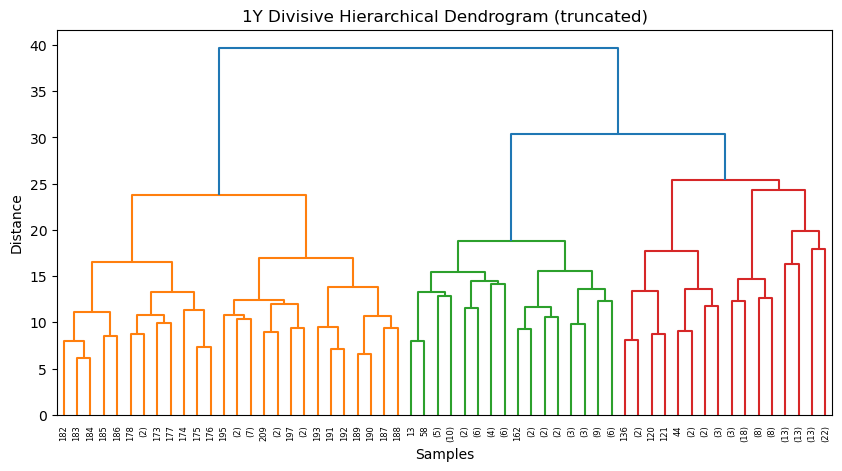

1Y cluster counts:
 3    111
2     63
1     36
Name: count, dtype: int64


In [11]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import matplotlib.pyplot as plt

# 🔹 Use Euclidean distance, Ward method is good for numeric data
Z1 = linkage(X1_scaled, method='ward', metric='euclidean')

# 🔹 Plot dendrogram to see cluster splits
plt.figure(figsize=(10, 5))
dendrogram(Z1, truncate_mode='level', p=5)  # show top 5 levels
plt.title("1Y Divisive Hierarchical Dendrogram (truncated)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# 🔹 Choose number of clusters (e.g., 3) and assign labels
clusters_1Y = fcluster(Z1, t=3, criterion='maxclust')
print("1Y cluster counts:\n", pd.Series(clusters_1Y).value_counts())


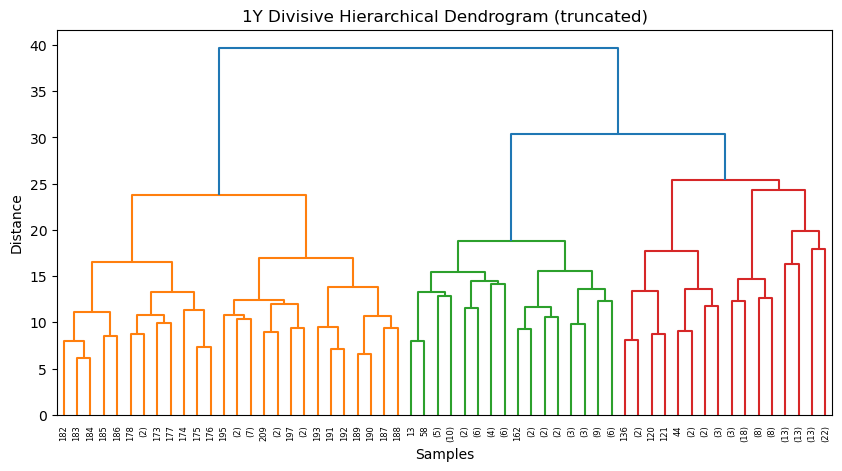

1Y cluster counts:
 3    111
2     63
1     36
Name: count, dtype: int64


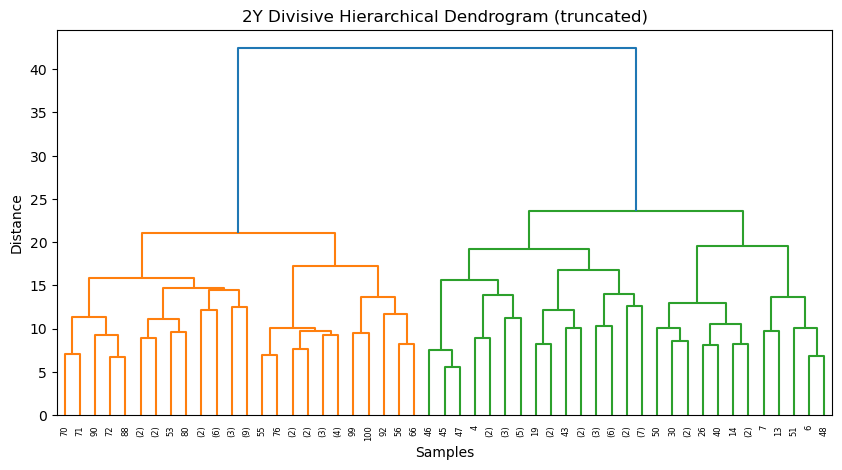

2Y cluster counts:
 1    49
2    38
3    14
Name: count, dtype: int64


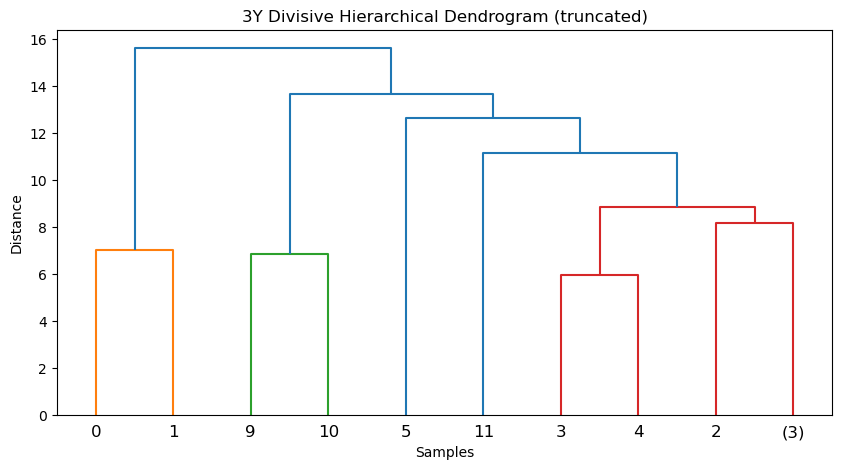

3Y cluster counts:
 2    10
1     2
Name: count, dtype: int64


In [12]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# 1Y DIVISIVE CLUSTERING
# ----------------------------
Z1 = linkage(X1_scaled, method='ward', metric='euclidean')

plt.figure(figsize=(10,5))
dendrogram(Z1, truncate_mode='level', p=5)
plt.title("1Y Divisive Hierarchical Dendrogram (truncated)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

clusters_1Y = fcluster(Z1, t=3, criterion='maxclust')
print("1Y cluster counts:\n", pd.Series(clusters_1Y).value_counts())

# ----------------------------
# 2Y DIVISIVE CLUSTERING
# ----------------------------
Z2 = linkage(X2_scaled, method='ward', metric='euclidean')

plt.figure(figsize=(10,5))
dendrogram(Z2, truncate_mode='level', p=5)
plt.title("2Y Divisive Hierarchical Dendrogram (truncated)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

clusters_2Y = fcluster(Z2, t=3, criterion='maxclust')
print("2Y cluster counts:\n", pd.Series(clusters_2Y).value_counts())

# ----------------------------
# 3Y DIVISIVE CLUSTERING
# ----------------------------
Z3 = linkage(X3_scaled, method='ward', metric='euclidean')

plt.figure(figsize=(10,5))
dendrogram(Z3, truncate_mode='level', p=5)
plt.title("3Y Divisive Hierarchical Dendrogram (truncated)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

clusters_3Y = fcluster(Z3, t=2, criterion='maxclust')  # e.g., 2 clusters for 3Y
print("3Y cluster counts:\n", pd.Series(clusters_3Y).value_counts())


In [13]:
from sklearn.metrics import silhouette_score

# 1Y Silhouette
sil_1Y = silhouette_score(X1_scaled, clusters_1Y)
print("1Y Silhouette Score:", sil_1Y)

# 2Y Silhouette
sil_2Y = silhouette_score(X2_scaled, clusters_2Y)
print("2Y Silhouette Score:", sil_2Y)

# 3Y Silhouette
sil_3Y = silhouette_score(X3_scaled, clusters_3Y)
print("3Y Silhouette Score:", sil_3Y)


1Y Silhouette Score: 0.04870883015091042
2Y Silhouette Score: 0.11886803948613109
3Y Silhouette Score: 0.20751324439330388
